<a href="https://colab.research.google.com/github/Kanishk-blip/-git_test-/blob/main/vgg16CompleteClassification2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import shutil
import zipfile
from google.colab import files
from sklearn.metrics import classification_report, confusion_matrix

print("✅ Libraries loaded.")


✅ Libraries loaded.


In [15]:
# Upload ZIP of dataset (e.g., solar-panel-images.zip)
print("📁 Upload the dataset ZIP file (e.g., solar-panel-images.zip)")
uploaded = files.upload()

for zip_file in uploaded:
    with zipfile.ZipFile(f"/content/{zip_file}", 'r') as zip_ref:
        zip_ref.extractall("/content/data")

print("✅ Dataset extracted to /content/data")


📁 Upload the dataset ZIP file (e.g., solar-panel-images.zip)


Saving archive (1).zip to archive (1) (1).zip
✅ Dataset extracted to /content/data


In [21]:
import os
import shutil

source_dir = "/content/data/Faulty_solar_panel"
binary_dir = "/content/binary_data"
os.makedirs(binary_dir, exist_ok=True)

# Print all folders in source to help find exact names
print("📂 Available folders:")
for cls in os.listdir(source_dir):
    print("-", cls)

# Smart copy based on partial match
copied = []
for cls in os.listdir(source_dir):
    cls_lower = cls.lower()
    if "bird" in cls_lower or "clean" in cls_lower:
        src = os.path.join(source_dir, cls)
        dst = os.path.join(binary_dir, cls)
        shutil.copytree(src, dst)
        copied.append(cls)

print("✅ Copied class folders:", copied)


📂 Available folders:
- Electrical-damage
- Clean
- Bird-drop
- Snow-Covered
- Physical-Damage
- Dusty
✅ Copied class folders: ['Clean', 'Bird-drop']


In [22]:
img_height = 244
img_width = 244
batch_size = 32
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/binary_data",
    validation_split=0.2,
    subset='training',
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/binary_data",
    validation_split=0.2,
    subset='validation',
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("✅ Classes loaded:", class_names)

# Prefetch and cache for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 400 files belonging to 2 classes.
Using 320 files for training.
Found 400 files belonging to 2 classes.
Using 80 files for validation.
✅ Classes loaded: ['Bird-drop', 'Clean']


In [23]:
base_model = tf.keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(img_height, img_width, 3)
)

# Freeze base model for initial training
base_model.trainable = False

# Build full model
inputs = tf.keras.Input(shape=(img_height, img_width, 3))
x = tf.keras.applications.vgg16.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1)(x)  # Binary output

model = tf.keras.Model(inputs, outputs)

# Show model summary
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 244, 244,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 244, 244)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 244, 244)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 244, 244)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 244, 244,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 244, 244,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        513 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=3,
            restore_best_weights=True,
            monitor='val_loss'
        )
    ]
)


Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.4943 - loss: 1.9132 - val_accuracy: 0.5625 - val_loss: 1.2669
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 265ms/step - accuracy: 0.4972 - loss: 1.6874 - val_accuracy: 0.5875 - val_loss: 1.0139
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step - accuracy: 0.6001 - loss: 1.3309 - val_accuracy: 0.6875 - val_loss: 0.8312
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 266ms/step - accuracy: 0.6792 - loss: 0.9251 - val_accuracy: 0.7250 - val_loss: 0.7373
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 269ms/step - accuracy: 0.6712 - loss: 0.7434 - val_accuracy: 0.7375 - val_loss: 0.6690
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 267ms/step - accuracy: 0.7178 - loss: 0.7294 - val_accuracy: 0.7375 - val_loss: 0.6211
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step - accuracy: 0.6936 - loss: 0.8712 - val_accuracy: 0.7875 - val_loss: 0.5501
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 265ms/step - accuracy: 0.7519 - loss: 0.6770 - val_accuracy: 0.81

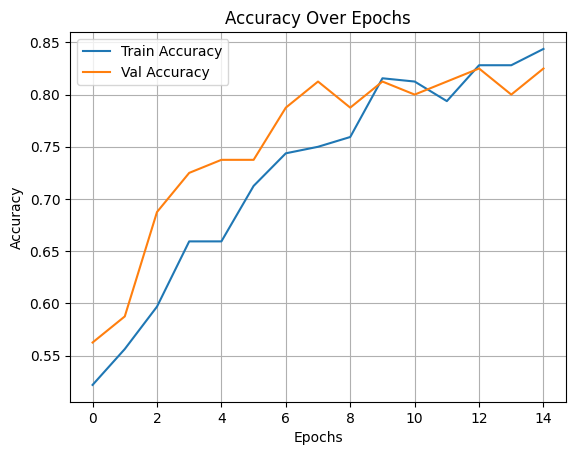

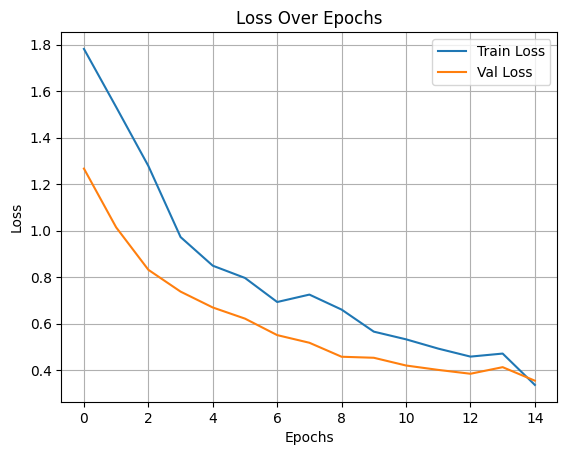

In [25]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 811ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step


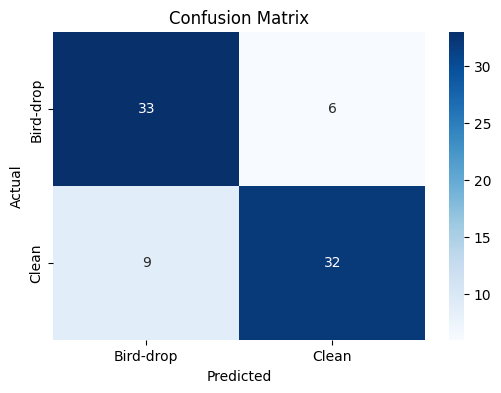

📋 Classification Report:
              precision    recall  f1-score   support

   Bird-drop       0.79      0.85      0.81        39
       Clean       0.84      0.78      0.81        41

    accuracy                           0.81        80
   macro avg       0.81      0.81      0.81        80
weighted avg       0.81      0.81      0.81        80



In [26]:
from sklearn.metrics import classification_report, confusion_matrix

# Collect predictions and true labels
all_preds = []
all_labels = []

for images, labels in val_ds:
    logits = model.predict(images)
    preds = tf.round(tf.sigmoid(logits)).numpy().flatten()
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print("📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


In [28]:
from tensorflow.keras.preprocessing import image
from google.colab import files

def predict_image(img_path):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Add batch dimension
    img_array = tf.keras.applications.vgg16.preprocess_input(img_array)

    # Predict
    logits = model.predict(img_array)[0][0]
    score = tf.sigmoid(logits).numpy()

    predicted_class = class_names[int(score > 0.5)]
    confidence = score if score > 0.5 else 1 - score

    print(f"\n✅ Predicted Class: {predicted_class} ({confidence:.2f} confidence)")

# Upload image
uploaded = files.upload()
for fn in uploaded.keys():
    predict_image(fn)


Saving 10.png to 10.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

✅ Predicted Class: Bird-drop (1.00 confidence)


In [31]:
model_save_path = "/content/bird_drop_clean_classifier.keras"
model.save(model_save_path)
print(f"✅ Model saved to: {model_save_path}")


✅ Model saved to: /content/bird_drop_clean_classifier.keras
